In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

import tqdm

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_inference import DPSO
from src.models.logger import DataLogger

from src.data_loader.evaluation_data_generator import DataGenerator

from src.data_loader.metrics import pose_err


In [35]:
model_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/model.yaml'
sonar_config_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/sonar.yaml'

data_root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/train/seq_1'
data_output_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output2'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

init_frames = model_config.TIME_WINDOW

from src.data_loader.transforms import SonarDatasetTranforms
data_generator = DataGenerator(data_root_dir, device, transforms = SonarDatasetTranforms)
data_lenght = data_generator.get_len()
print(f'Data generator initialized.')
print(f'Data series lenght: {data_lenght}')

Data generator initialized.
Data series lenght: 500


In [36]:
# init DPSO

ckpt_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output/test_ckpt.ckpt'

model = DPSO(model_config_pth, sonar_config_pth, device, output_data_pth = data_output_dir)
model.load_state_dict(torch.load(ckpt_pth, weights_only=True))
model.eval()

err_logger = DataLogger(data_output_dir, 'err.csv', ['translation_error', 'rot_error'], 10)

In [ ]:

limit_frames = 50 
total_translation_err = 0.0
total_rot_err = 0.0

with torch.no_grad():

    with tqdm(range(limit_frames)) as pbar:
        for frame_idx in pbar:

            # t, frame, pose, frame_np = data_generator.get_sample(frame_idx, return_visu=True)
            
            t, frame, pose_gt = data_generator.get_sample(frame_idx, return_visu=False)
            
            if frame_idx <= init_frames:
                model.init_step(frame, t, pose_gt)
        
            else:
                n, t_, pose_pred = model(frame, t, debug_logger=False)

                translation_err, rot_err = pose_err(pose_pred.view(1, 1, 7), pose_gt.view(1, 1, 7))

                total_translation_err += translation_err
                total_rot_err += rot_err
                
                err_logger.log([translation_err.detach().cpu().numpy(), 
                                rot_err.detach().cpu().numpy()])
                
           
                pbar.set_description(f'Frame: {frame_idx}/{limit_frames}\nATE: translation: {total_translation_err/frame_idx:.3f}, rotation: {total_rot_err/frame_idx:.3f}')

model.close()

Err: translation: 0.242950439453125, rotation: tensor([0.0593])
Err: translation: 0.09049147367477417, rotation: tensor([0.1759])
Err: translation: 0.2886104881763458, rotation: tensor([0.2571])
Err: translation: 0.7469339370727539, rotation: tensor([0.4262])
Err: translation: 1.2770678997039795, rotation: tensor([0.5778])
Err: translation: 1.956687331199646, rotation: tensor([0.7486])
Err: translation: 2.4659717082977295, rotation: tensor([0.8614])
Err: translation: 3.002439260482788, rotation: tensor([0.9640])
Err: translation: 3.603334903717041, rotation: tensor([1.0722])
Err: translation: 4.174463272094727, rotation: tensor([1.1602])
Err: translation: 5.050695419311523, rotation: tensor([1.3197])
Err: translation: 5.9113640785217285, rotation: tensor([1.4797])
Err: translation: 6.87439489364624, rotation: tensor([1.6407])
Err: translation: 7.660635471343994, rotation: tensor([1.7830])
Err: translation: 8.332110404968262, rotation: tensor([1.8891])
Err: translation: 9.43410491943359

In [43]:
prim_traj_pth = os.path.join(data_output_dir, 'prim_traj_estim.csv')
sec_traj_pth = os.path.join(data_output_dir, 'sec_traj_estim.csv')
pts_pth = os.path.join(data_output_dir, 'pts3d.csv')

data_generator.read_estim_trajectory(prim_traj_pth, 'primary estim traj')
data_generator.read_estim_trajectory(sec_traj_pth, 'secondary estim traj')
data_generator.read_pts(pts_pth)

[autoreload of src.data_loader.metrics failed: Traceback (most recent call last):
  File "c:\Users\janis\miniconda3\envs\so\lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "c:\Users\janis\miniconda3\envs\so\lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "c:\Users\janis\miniconda3\envs\so\lib\importlib\__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 619, in _exec
  File "<frozen importlib._bootstrap_external>", line 879, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1017, in get_code
  File "<frozen importlib._bootstrap_external>", line 947, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_removed
  File "c:\Users\janis\Projekty\Magisterka\SonarOdometry\src\data_loader\metrics.py", line 50
    def ATE():
              ^


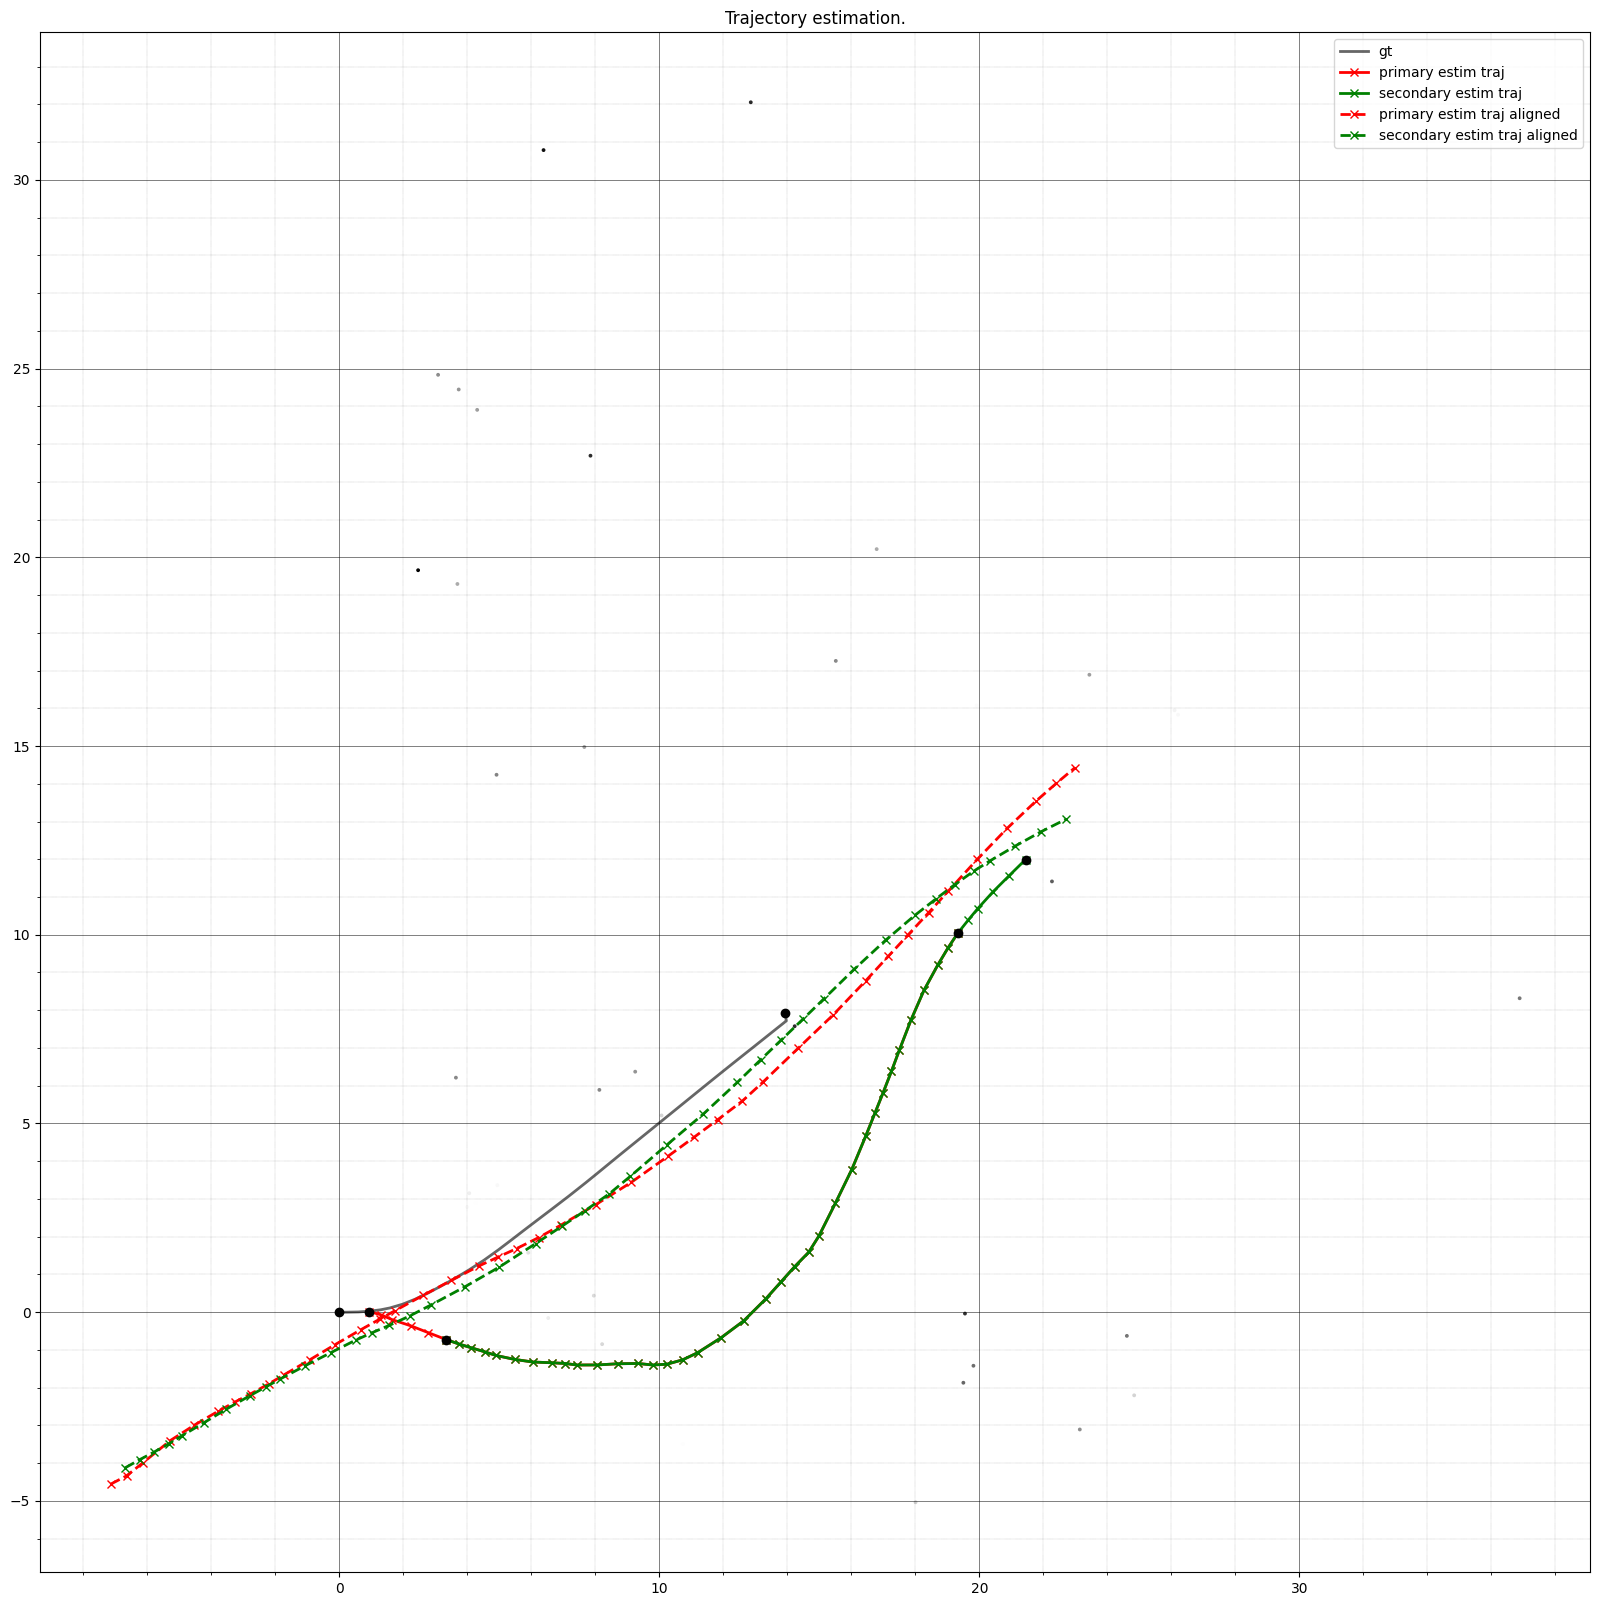

c:\Users\janis\Projekty\Magisterka\SonarOdometry\src\data_loader\metrics.py:33: UserWarning: Optimal rotation is not uniquely or poorly defined for the given sets of vectors.
  r = R.from_quat(q_pred)


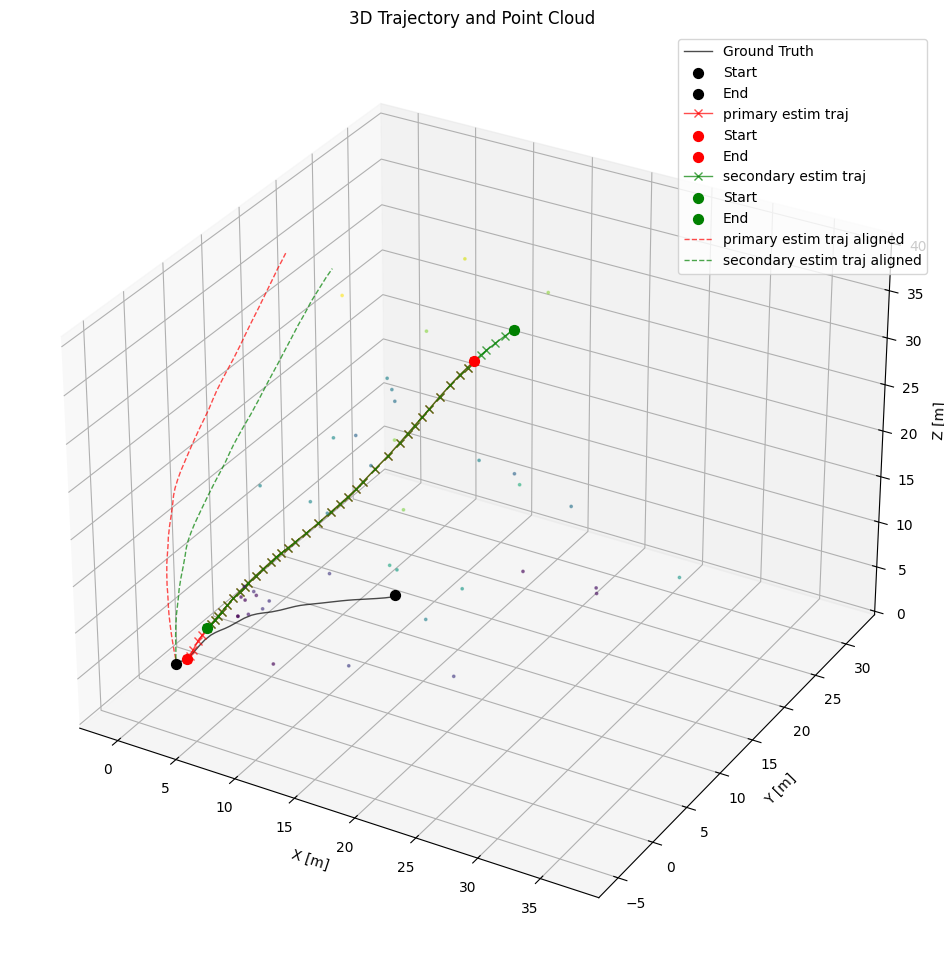

In [47]:
data_generator.generate_trajectory_map_2d(plane = 'xy', start = 0, end = 1, show = {'gt':True,'traj':True,'pts':True, 'align':True})

data_generator.generate_trajectory_map_3d()


In [ ]:
# from training.metrics import pose_err

# metrircs = {'ATE':pose_err}
# data_generator.print_metrics(metrircs)
     

--- ATE ---


ValueError: not enough values to unpack (expected 3, got 2)